In [30]:
import trino
from trino.dbapi import connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg as pg
import pymysql

In [7]:
%pip install psycopg

Note: you may need to restart the kernel to use updated packages.


In [27]:
%pip install PyMySQL

Note: you may need to restart the kernel to use updated packages.


In [219]:
# все переменные, соединия, etc

iceberg_bucket = "local/iceberg"

trino_creds = dict(
    host = "localhost",
    port = 8081,
    user = "jupyter"
)

iceberg_creds = trino_creds.copy()
iceberg_creds.update(
    dict(
        catalog="iceberg",
        schema="student_superstore"
    )
)

trino_creds_upd = trino_creds.copy()
trino_creds_upd.update(
    dict(    
        catalog="system",   
        schema="runtime",
    )
)

pg_creds = dict(
    host='localhost',
    port=5432,
    user='postgres',
    password='postgres',
    dbname='iceberg'
)

mysql_creds = dict(
    host="localhost",
    port=3307,
    user="demo",
    passwd="root",
    db="demo",
    charset="utf8mb4",
)

In [17]:
df = pd.read_csv("Sample - Superstore.csv", encoding='cp1252')

df.columns = [col.strip().replace(" ", "_").replace("-", "_") for col in df.columns]
orders_cols = [
    "Row_ID", "Order_ID", "Order_Date", "Ship_Date", "Ship_Mode",
    "Customer_ID", "Customer_Name", "Segment", "Country", "City",
    "State", "Postal_Code", "Region",
]
items_cols = [
    "Row_ID", "Product_ID", "Category", "Sub_Category",
    "Product_Name", "Sales", "Quantity", "Discount", "Profit",
]

df_orders = df[orders_cols].copy()
df_items = df[items_cols].copy()

df_orders["Order_Date"] = pd.to_datetime(df_orders["Order_Date"])
df_orders["Ship_Date"] = pd.to_datetime(df_orders["Ship_Date"])

In [214]:
print(df_orders.shape)
print(df_items.shape)

(9994, 13)
(9994, 9)


In [216]:
# Заливаем данные в pg

pg_conn = pg.connect(**pg_creds)
table_ddl_pg = """
    CREATE TABLE IF NOT EXISTS superstore_orders (
      row_id        INTEGER PRIMARY KEY,
      order_id      VARCHAR(64),
      order_date    DATE,
      ship_date     DATE,
      ship_mode     VARCHAR(64),
      customer_id   VARCHAR(64),
      customer_name VARCHAR(255),
      segment       VARCHAR(64),
      country       VARCHAR(128),
      city          VARCHAR(128),
      state         VARCHAR(128),
      postal_code   VARCHAR(32),
      region        VARCHAR(64)
    )
    """

insert_pg = """
    INSERT INTO superstore_orders (
      row_id, order_id, order_date, ship_date, ship_mode,
      customer_id, customer_name, segment, country, city,
      state, postal_code, region
    ) VALUES (
      %(Row_ID)s, %(Order_ID)s, %(Order_Date)s, %(Ship_Date)s, %(Ship_Mode)s,
      %(Customer_ID)s, %(Customer_Name)s, %(Segment)s, %(Country)s, %(City)s,
      %(State)s, %(Postal_Code)s, %(Region)s
    )
    ON CONFLICT (row_id) DO NOTHING
"""


with pg_conn.cursor() as curr:

    curr.execute(table_ddl_pg)
    pg_conn.commit()

    curr.executemany(insert_pg, df_orders.to_dict(orient="records"))
    print("Залито строк в pg:", curr.rowcount)
    pg_conn.commit()
# pg_conn.close()

Залито строк в pg: 9994


In [217]:
with pg_conn.cursor() as curr:
    curr.execute('select count(*) from public.superstore_orders')
    print(curr.fetchall())

[(9994,)]


In [227]:
# Заливаем данные в mysql
my_conn = pymysql.connect(**mysql_creds)
my_conn.autocommit(True)

my_table_ddl = """
    CREATE TABLE IF NOT EXISTS superstore_items (
      row_id        INT PRIMARY KEY,
      product_id    VARCHAR(64),
      category      VARCHAR(64),
      sub_category  VARCHAR(64),
      product_name  VARCHAR(255),
      sales         DOUBLE,
      quantity      INT,
      discount      DOUBLE,
      profit        DOUBLE
)
"""


insert_my = """
    INSERT INTO superstore_items (
      row_id, product_id, category, sub_category,
      product_name, sales, quantity, discount, profit
    ) VALUES (
      %(Row_ID)s, %(Product_ID)s, %(Category)s, %(Sub_Category)s,
      %(Product_Name)s, %(Sales)s, %(Quantity)s, %(Discount)s, %(Profit)s
    )
    ON DUPLICATE KEY UPDATE
      product_id=VALUES(product_id),
      category=VALUES(category),
      sub_category=VALUES(sub_category),
      product_name=VALUES(product_name),
      sales=VALUES(sales),
      quantity=VALUES(quantity),
      discount=VALUES(discount),
      profit=VALUES(profit)
"""
with  my_conn.cursor() as my_cur:
    my_cur.execute(my_table_ddl)
    my_conn.commit()

    my_cur.executemany(insert_my, df_items.to_dict(orient="records"))
    print("Залито строк в MySQL:", my_cur.rowcount)
    my_conn.commit()

Залито строк в MySQL: 0


In [228]:
with my_conn.cursor() as curr:
    curr.execute('select count(*) from superstore_items')
    print(curr.fetchall())

((9994,),)


In [230]:
conn_pg.close()
my_conn.close()

Error: Already closed

In [231]:
# делаем проверку что у нас там в trino лежит

trino_conn = connect(**trino_creds_upd)

with trino_conn.cursor() as trino_curr:
    trino_curr.execute("SHOW CATALOGS")
    catalogs = trino_curr.fetchall()
catalogs

[['hive'], ['iceberg'], ['mysql'], ['postgres'], ['system']]

Ура, наконец-то все базы и minio/iceberg появились в Trino :)

In [224]:
trino_query = """
SHOW TABLES FROM postgres.public
"""
with trino_conn.cursor() as trino_curr:
    trino_curr.execute(trino_query)
    print(trino_curr.fetchall())

[['iceberg_namespace_properties'], ['iceberg_tables'], ['superstore_orders']]


## 1. Аггрегирующий sql запрос - наибольшее количество заказов по месяцам (pg)

In [225]:
pg_query = f"""
    SELECT
         date_trunc('month', o.order_date) AS order_month,
        COUNT(*) AS orders_cnt
    FROM postgres.public.superstore_orders AS o
    GROUP BY 1
    ORDER BY 2 DESC
"""

df_orders_by_date = pd.read_sql(pg_query, trino_conn)
df_orders_by_date.head()

C:\Users\Daniel\AppData\Local\Temp\ipykernel_43880\2696115135.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_orders_by_date = pd.read_sql(pg_query, trino_conn)


,order_month,orders_cnt
0,2017-12-01,462
1,2017-11-01,459
2,2017-09-01,459
3,2016-11-01,370
4,2016-09-01,363


## 2. Аггрегирующий sql запрос -продажи по категориям (mysql)

In [232]:
msql_query = f"""
    SELECT
        i.category,
        ROUND(SUM(i.sales),2) AS total_sales,
        SUM(i.quantity) AS total_qty,
        ROUND(SUM(i.profit),2) AS total_profit
    FROM mysql.demo.superstore_items AS i
    GROUP BY i.category
    ORDER BY total_sales DESC
"""
df_sales_by_category = pd.read_sql(msql_query, trino_conn)
df_sales_by_category.head()

C:\Users\Daniel\AppData\Local\Temp\ipykernel_43880\841688828.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales_by_category = pd.read_sql(msql_query, trino_conn)


DatabaseError: Execution failed on sql: 
    SELECT
        i.category,
        ROUND(SUM(i.sales),2) AS total_sales,
        SUM(i.quantity) AS total_qty,
        ROUND(SUM(i.profit),2) AS total_profit
    FROM mysql.demo.superstore_items AS i
    GROUP BY i.category
    ORDER BY total_sales DESC

TrinoExternalError(type=EXTERNAL, name=JDBC_ERROR, message="Could not create connection to database server. Attempted reconnect 3 times. Giving up.", query_id=20260112_013918_00007_wxttf)
unable to rollback

## 3. Аггрегирующий sql запрос - общая выручка по региону и сегменту. (pg + mysql)

In [155]:
pg_mysql_query = f"""
    SELECT
        o.region,
        o.segment,
        DATE_TRUNC('month', o.order_date) AS order_month,
        SUM(i.sales) AS total_sales,
        SUM(i.profit) AS total_profit,
        SUM(i.quantity) AS total_qty
    FROM  postgres.public.superstore_orders AS o
    JOIN mysql.demo.superstore_items AS i
      ON o.row_id = i.row_id
    GROUP BY
        o.region,
        o.segment,
        DATE_TRUNC('month', o.order_date)
    ORDER BY
        o.region,
        o.segment,
        order_month
"""

df_region_segment_month = pd.read_sql(pg_mysql_query, trino_conn)
df_region_segment_month.head()

C:\Users\Daniel\AppData\Local\Temp\ipykernel_43880\2056494836.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_region_segment_month = pd.read_sql(pg_mysql_query, trino_conn)


,region,segment,order_month,total_sales,total_profit,total_qty
0,Central,Consumer,2014-01-01,1099.206,139.7119,50
1,Central,Consumer,2014-02-01,1139.180,269.9888,56
2,Central,Consumer,2014-03-01,3877.690,-458.6878,91
3,Central,Consumer,2014-04-01,2835.652,-47.8489,61
4,Central,Consumer,2014-05-01,1726.586,-445.6287,74


In [156]:
# 1) по месяцам
df_orders_by_date["metric_type"] = "orders_per_month"
df_orders_by_date_agg = df_orders_by_date.rename(columns={
    "order_month": "dimension",
    "orders_cnt": "metric_value"
})[["dimension", "metric_value", "metric_type"]]

# 2) по категориям
df_sales_by_category["metric_type"] = "sales_per_category"
df_sales_by_category_agg = df_sales_by_category.rename(columns={
    "category": "dimension",
    "total_sales": "metric_value"
})[["dimension", "metric_value", "metric_type"]]

# 3) по региону и сегменту 
df_region_segment_month["dimension"] = (
    df_region_segment_month["region"] + " | " +
    df_region_segment_month["segment"] + " | " +
    df_region_segment_month["order_month"].astype(str)
)
df_region_segment_month_agg = df_region_segment_month.rename(columns={
    "total_sales": "metric_value"
})[["dimension", "metric_value"]]
df_region_segment_month_agg["metric_type"] = "sales_region_segment_month"

# Финальный DF
final_df = pd.concat(
    [df_orders_by_date_agg, df_sales_by_category_agg, df_region_segment_month_agg],
    ignore_index=True
)
final_df.head()

,dimension,metric_value,metric_type
0,2017-12-01,462.0,orders_per_month
1,2017-11-01,459.0,orders_per_month
2,2017-09-01,459.0,orders_per_month
3,2016-11-01,370.0,orders_per_month
4,2016-09-01,363.0,orders_per_month


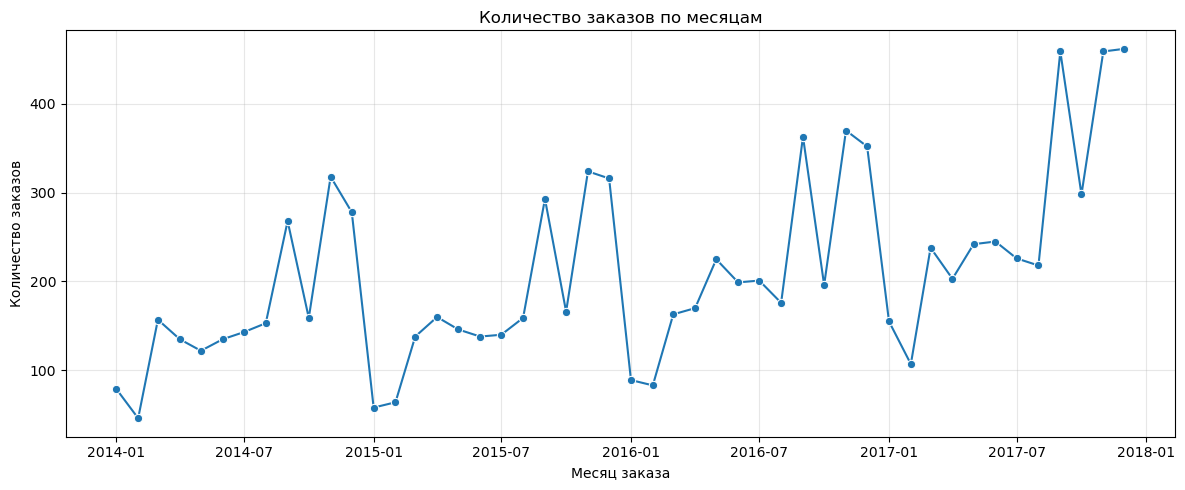

In [157]:
df_month = final_df[final_df["metric_type"] == "orders_per_month"].copy()
df_month = df_month.sort_values("dimension")

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_month,
    x="dimension",
    y="metric_value",
    marker="o"
)
plt.title("Количество заказов по месяцам")
plt.xlabel("Месяц заказа")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

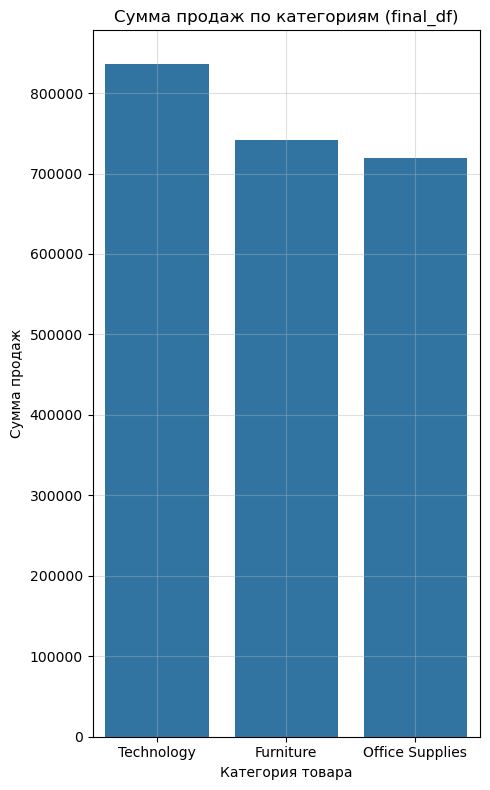

In [158]:
df_cat = final_df[final_df["metric_type"] == "sales_per_category"].copy()
df_cat = df_cat.sort_values("metric_value", ascending=False)

plt.figure(figsize=(5, 8))
sns.barplot(
    data=df_cat,
    x="dimension",
    y="metric_value"
)
plt.title("Сумма продаж по категориям (final_df)")
plt.xlabel("Категория товара")
plt.ylabel("Сумма продаж")
plt.tight_layout()
plt.grid(True, alpha=0.4)
plt.show()


## Сохранение данных в Iceberg

In [203]:
create_schema_sql = f"""
    CREATE SCHEMA IF NOT EXISTS iceberg.student_superstore
"""
# conn_ice = connect(**iceberg_creds)
with trino_conn.cursor() as cur_trino:
    cur_trino.execute(create_schema_sql)
    conn_ice.commit()

TrinoQueryError: TrinoQueryError(type=INTERNAL_ERROR, name=GENERIC_INTERNAL_ERROR, message="Failed to execute exists query: SELECT table_namespace FROM iceberg_tables WHERE catalog_name = ? AND  (table_namespace = ? OR table_namespace LIKE ? ESCAPE '!') LIMIT 1", query_id=20260112_011951_00003_ma4gr)

In [200]:
# rows = []
# for row in final_df.itertuples(index=False):
#     dim = str(row.dimension).replace("'", "''")
#     metric_value = float(row.metric_value)
#     metric_type = str(row.metric_type).replace("'", "''")
#     rows.append(f"('{dim}', {metric_value}, '{metric_type}')")

# values_clause = ",\n".join(rows)

# insert_sql = f"""
# INSERT INTO {iceberg_catalog}.{iceberg_schema}.{iceberg_table} (dimension, metric_value, metric_type)
# VALUES
# {values_clause}
# """

with conn_ice.cursor() as cur:
    # cur.execute(insert_sql)
    cur.execute("SHOW SCHEMAS FROM iceberg")
    print(cur.fetchall())

TrinoQueryError: TrinoQueryError(type=INTERNAL_ERROR, name=GENERIC_INTERNAL_ERROR, message="Cannot check and eventually update SQL schema", query_id=20260112_011638_00002_ma4gr)

In [ ]:
check_sql = f"""
SELECT
    metric_type,
    COUNT(*) AS rows_cnt,
    MIN(metric_value) AS min_value,
    MAX(metric_value) AS max_value
FROM {iceberg_catalog}.{iceberg_schema}.{iceberg_table}
GROUP BY metric_type
ORDER BY metric_type
"""

df_check_ice = pd.read_sql(check_sql, conn_ice)
df_check_ice
